<a href="https://colab.research.google.com/github/MahiraMohammed/ABC-Basket-Ball-Company-Python-Project/blob/main/Machine_Learning_classification_project_on_Student_depression_prediction(final).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🎓Student depression prediction project**


Welcome to the Student Depression Prediction project!
In this notebook, we walk through a complete Machine Learning pipeline to predict whether a student is experiencing depression based on various academic and personal factors.

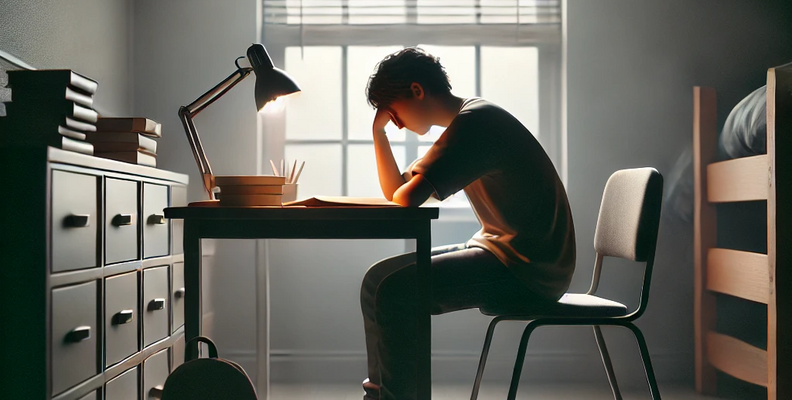

# 🧠 **Problem Statement**
Mental health issues among students, especially depression, have become a growing concern worldwide. Early detection of depressive tendencies can lead to timely interventions and support. However, manual identification through surveys or counseling is not always feasible at scale.


# **🎯 Goal of the Project:** The primary objective of this project is to:

Build a robust machine learning model that can predict whether a student is experiencing depression based on their personal, academic, and social information.

Key Objectives:

✅ Understand the key factors associated with student depression

✅ Preprocess and explore the dataset to gain insights

✅ Train and evaluate multiple machine learning models

✅ Fine-tune the best-performing model for optimal accuracy

✅ Save and deploy the final model for real-world use

✅ Create a user-friendly, report-style notebook for presentation



Let's begin! 🚀

📦 Step 1: Importing Required Libraries.

Let's load the essential libraries for data handling, visualization, and modeling.

📚 Step 1: Importing Required Libraries
Here we import the essential Python libraries needed for:

Data manipulation (pandas, numpy)

Visualization (matplotlib, seaborn)
These will help us throughout the entire data science workflow.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

📂 Step 2: Loading the Dataset
We load our dataset using pandas.read_csv().
This dataset contains student information with various features that might indicate depressive symptoms. Let's bring it into our workspace.

In [29]:
df=pd.read_csv('/content/student_depression_dataset.csv')

👁️ Step 3: Previewing the Data
Using df.head(), we display the first few rows to understand:

What features (columns) are available

How the data looks at a glance
This gives us an initial feel for the dataset.

In [30]:
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


🧾 Step 4: Dataset Information
df.info() helps us inspect:

Column names and data types

Non-null value counts

Overall memory usage
This step helps us check for missing values and understand feature formats.

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

🔢 Step 5: Dataset Dimensions
We use df.shape to get the total number of rows and columns in our dataset.
This gives us a sense of the dataset's size.

In [32]:
df.shape

(27901, 18)

📊 Step 6: Statistical Summary
Using df.describe(), we summarize all numeric columns by calculating:

Mean

Standard deviation

Minimum and maximum

Quartiles (25%, 50%, 75%)
It helps spot any potential anomalies or data ranges.

In [33]:
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,1.000000


🕵️ Step 7: Missing Values Check
Let's check for missing values in each column using df.isnull().sum().
Handling missing data is crucial for model performance and reliability.

🧹 Step 4: Data Preprocessing

Before training a model, we must prepare our data. This includes:

- Handling missing values
- Encoding categorical variables (using Label Encoding or One-Hot Encoding)
- Converting data types where needed
- Dropping unnecessary columns

Proper preprocessing ensures our model learns effectively.


In [34]:
df.isnull().sum()

,0
id,0
Gender,0
Age,0
City,0
Profession,0
Academic Pressure,0
Work Pressure,0
CGPA,0
Study Satisfaction,0
Job Satisfaction,0


🧹 Step 8: Duplicate Values Check
We use df.duplicated().sum() to detect duplicate records.
Cleaning duplicates is important for accurate modeling.

In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df.drop('id',axis=1,inplace=True)

In [37]:
df['Age'].value_counts()

,count
Age,
24.0,2258
20.0,2237
28.0,2133
29.0,1950
33.0,1893
25.0,1784
21.0,1726
23.0,1645
18.0,1587


In [38]:
bins = [17, 20, 25, 30, 35, 60]
labels = ['18-20', '21-25', '26-30', '31-35', '36+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)


In [39]:
df = df.drop(columns=['Age'])

In [40]:
print(df['Age_Group'].value_counts())

Age_Group
21-25    8573
26-30    7845
31-35    6060
18-20    5384
36+        39
Name: count, dtype: int64


In [41]:
df['Profession'].value_counts()

,count
Profession,
Student,27870
Architect,8
Teacher,6
'Digital Marketer',3
Chef,2
'Content Writer',2
Pharmacist,2
Doctor,2
'UX/UI Designer',1


In [42]:
df.drop('Profession',axis=1,inplace=True)

In [43]:
df['Academic Pressure'].value_counts()

,count
Academic Pressure,
3.0,7462
5.0,6296
4.0,5155
1.0,4801
2.0,4178
0.0,9


In [44]:
# Replace 0.0 with 1.0 in the 'Academic Pressure' column
df['Academic Pressure'] = df['Academic Pressure'].replace(0.0, 1.0)

# Check the counts after replacement
print(df['Academic Pressure'].value_counts())


Academic Pressure
3.0    7462
5.0    6296
4.0    5155
1.0    4810
2.0    4178
Name: count, dtype: int64


In [45]:
df['Study Satisfaction'].value_counts()

,count
Study Satisfaction,
4.0,6359
2.0,5838
3.0,5821
1.0,5451
5.0,4422
0.0,10


In [46]:
# Replace 0.0 with 1.0
df['Study Satisfaction'] = df['Study Satisfaction'].replace(0.0, 1.0)

# Check updated distribution
print(df['Study Satisfaction'].value_counts())


Study Satisfaction
4.0    6359
2.0    5838
3.0    5821
1.0    5461
5.0    4422
Name: count, dtype: int64


In [47]:
df['Sleep Duration'].value_counts()

,count
Sleep Duration,
'Less than 5 hours',8310
'7-8 hours',7346
'5-6 hours',6183
'More than 8 hours',6044
Others,18


In [48]:
print(df['Sleep Duration'].unique())

["'5-6 hours'" "'Less than 5 hours'" "'7-8 hours'" "'More than 8 hours'"
 'Others']


In [49]:
# Remove leading and trailing single quotes from all values in 'Sleep Duration'
df['Sleep Duration'] = df['Sleep Duration'].str.strip("'")



In [50]:
df['Sleep Duration'] = df['Sleep Duration'].replace('Others', 'Less than 5 hours')


In [51]:
df['Dietary Habits'].value_counts()

,count
Dietary Habits,
Unhealthy,10317
Moderate,9921
Healthy,7651
Others,12


In [52]:
df['Dietary Habits'] = df['Dietary Habits'].replace('Others', 'Unhealthy')


In [53]:
df['Degree'].value_counts()

,count
Degree,
'Class 12',6080
B.Ed,1867
B.Com,1506
B.Arch,1478
BCA,1433
MSc,1190
B.Tech,1152
MCA,1044
M.Tech,1022


In [54]:
def bin_degree(degree):
    degree = degree.strip("'")  # remove extra quotes
    if degree == 'Class 12':
        return 'Graduate'  # assuming "Graduate" means someone who completed school
    elif degree.startswith('B'):
        return 'Undergraduate'
    elif degree.startswith('M') or degree in ['PhD', 'MD', 'LLM']:
        return 'Masters'
    else:
        return 'Others'

df['Degree_Binned'] = df['Degree'].apply(bin_degree)


In [55]:
df['Degree_Binned'] = df['Degree'].apply(bin_degree)

In [56]:
df['Degree_Binned'].value_counts()

,count
Degree_Binned,
Undergraduate,11968
Masters,9147
Graduate,6080
Others,706


In [57]:
df.drop('Degree',axis=1,inplace=True)

In [58]:
df['Financial Stress'].value_counts()

,count
Financial Stress,
5.0,6715
4.0,5775
3.0,5226
1.0,5121
2.0,5061
?,3


In [59]:
# Remove rows where Financial Stress is '?'
df = df[df['Financial Stress'] != '?']

# Optionally convert column to float
df['Financial Stress'] = df['Financial Stress'].astype(float)


<ipython-input-59-1a6032211a25>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Financial Stress'] = df['Financial Stress'].astype(float)


In [60]:
df = df[df['Financial Stress'] != '?'].copy()
df['Financial Stress'] = df['Financial Stress'].astype(float)


In [61]:
df['Depression'].value_counts()

,count
Depression,
1,16335
0,11563


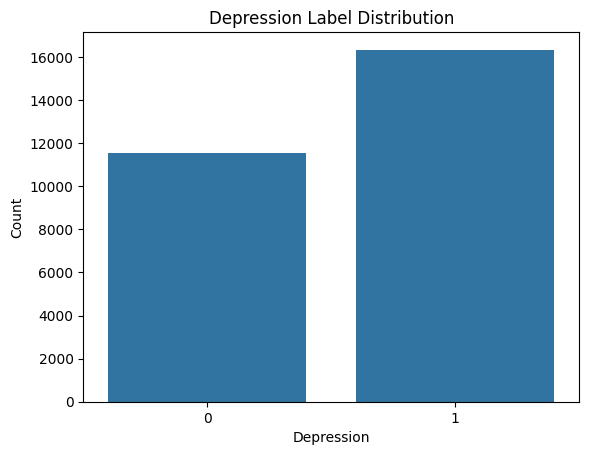

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Depression', data=df)
plt.title("Depression Label Distribution")
plt.xlabel("Depression")
plt.ylabel("Count")
plt.show()


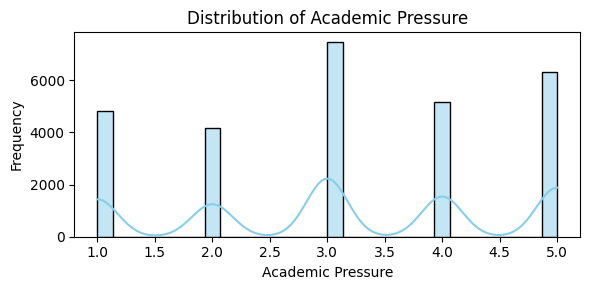

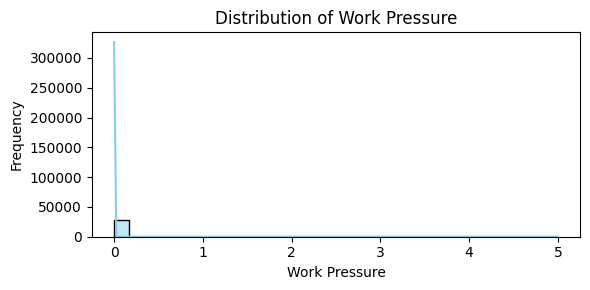

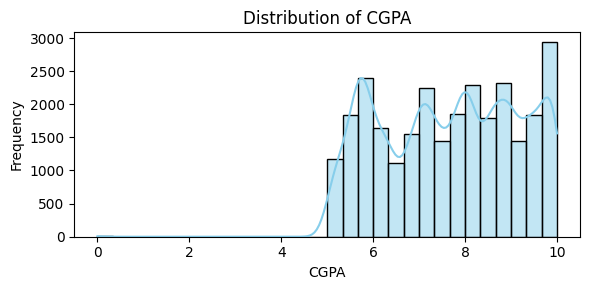

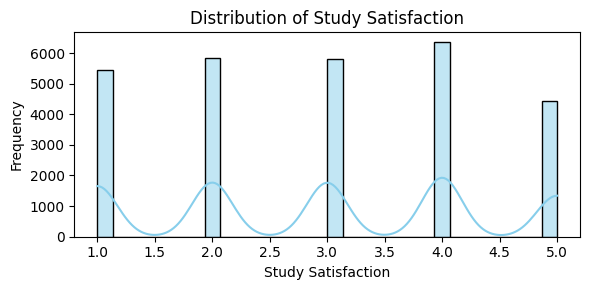

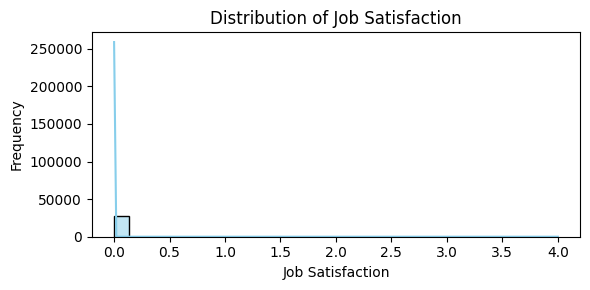

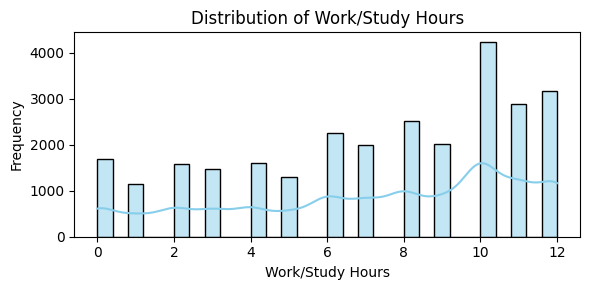

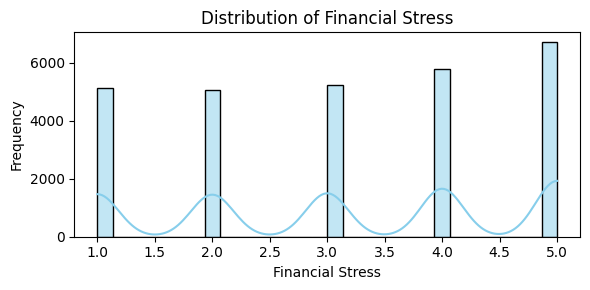

In [63]:
# Identify numeric columns (excluding target)
num_cols = df.select_dtypes("number").columns.tolist()
if "Depression" in num_cols:
    num_cols.remove("Depression")

# Plot histograms
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col], bins=30, kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [64]:
df.drop('Work Pressure',axis=1,inplace=True)

In [65]:
df.drop('Job Satisfaction',axis=1,inplace=True)

In [66]:
df['CGPA'].value_counts()

,count
CGPA,
8.0400,821
9.9600,425
5.7400,410
8.9500,371
9.2100,343
...,...
6.6400,1
7.0625,1
6.9800,1


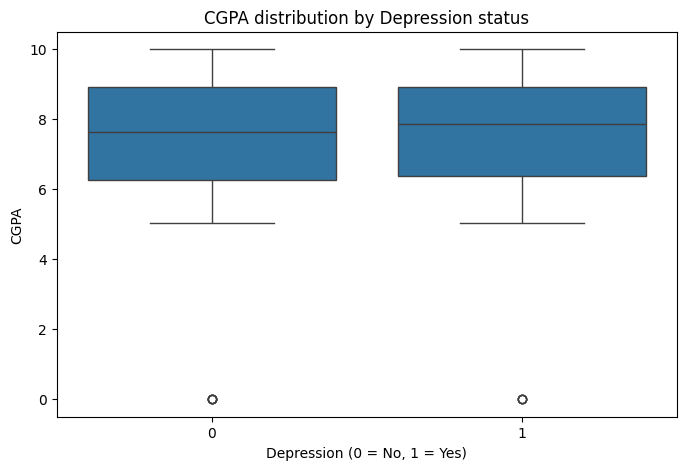

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x='Depression', y='CGPA', data=df)
plt.title('CGPA distribution by Depression status')
plt.xlabel('Depression (0 = No, 1 = Yes)')
plt.ylabel('CGPA')
plt.show()


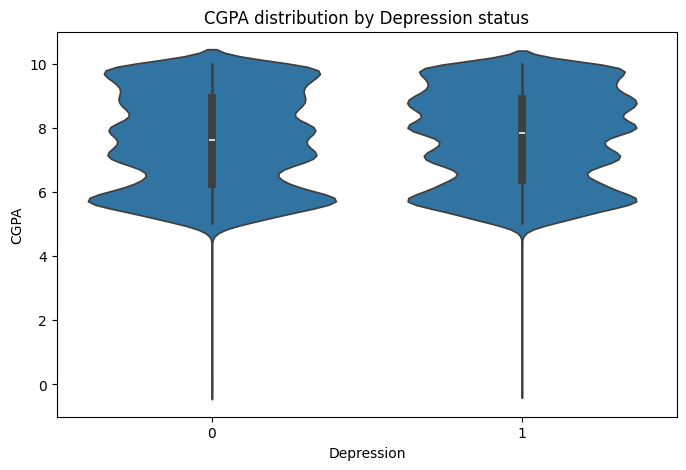

In [68]:
plt.figure(figsize=(8,5))
sns.violinplot(x='Depression', y='CGPA', data=df)
plt.title('CGPA distribution by Depression status')
plt.show()


In [69]:
print(df.groupby('Depression')['CGPA'].mean())


Depression
0    7.617236
1    7.683713
Name: CGPA, dtype: float64


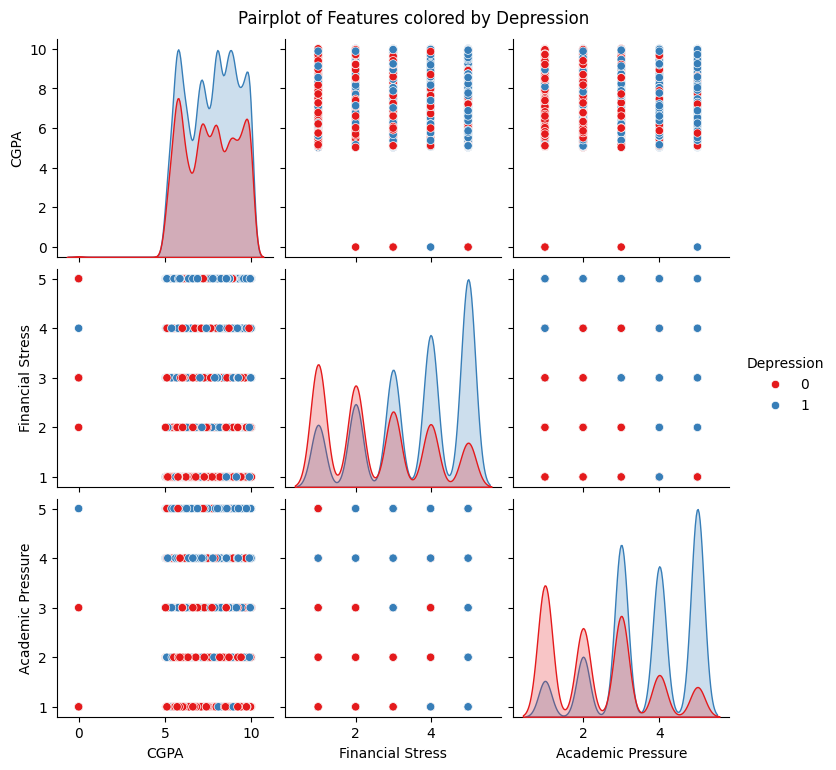

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant numeric columns and target
features = ['CGPA', 'Financial Stress', 'Academic Pressure', 'Depression']

# Plot pairplot colored by Depression
sns.pairplot(df[features], hue='Depression', diag_kind='kde', palette='Set1')
plt.suptitle('Pairplot of Features colored by Depression', y=1.02)
plt.show()


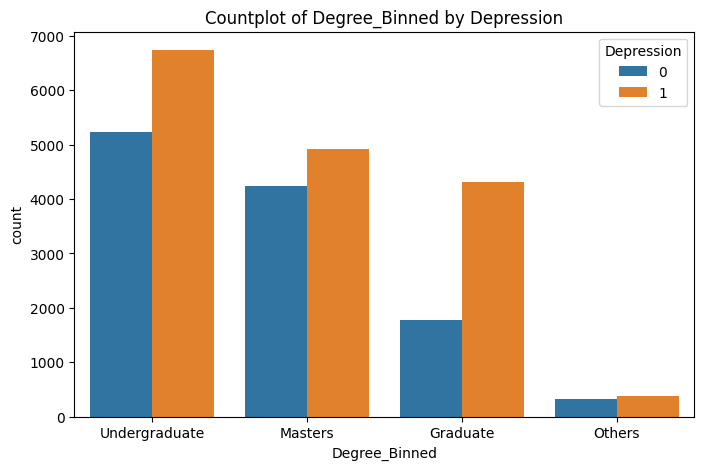

In [71]:
plt.figure(figsize=(8,5))
sns.countplot(x='Degree_Binned', hue='Depression', data=df)
plt.title('Countplot of Degree_Binned by Depression')
plt.show()


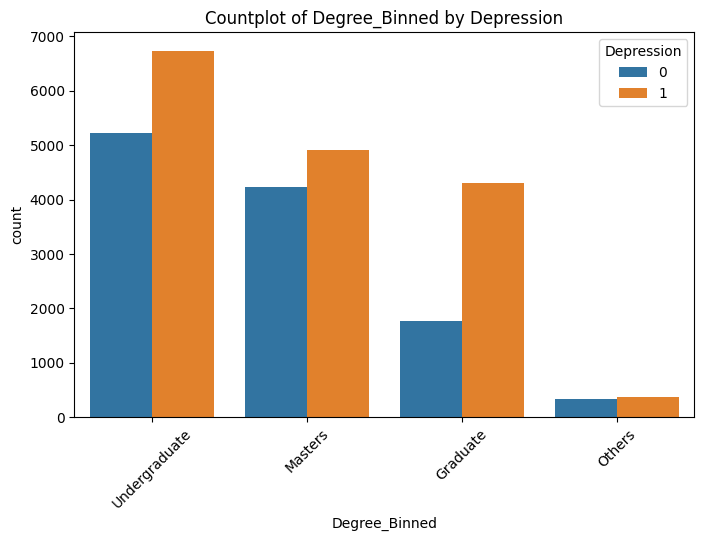

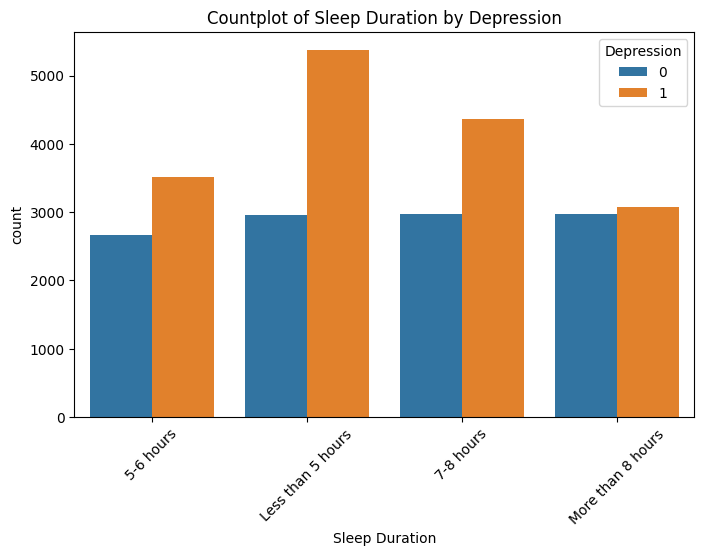

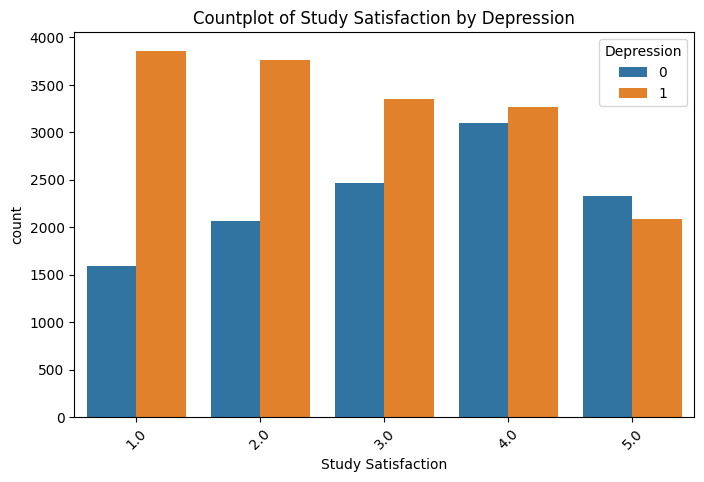

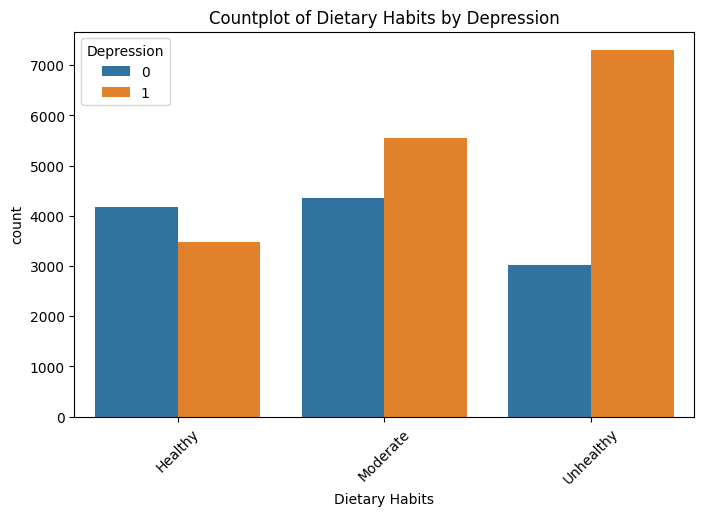

In [72]:
categorical_features = ['Degree_Binned', 'Sleep Duration', 'Study Satisfaction', 'Dietary Habits']

for feature in categorical_features:
    plt.figure(figsize=(8,5))
    sns.countplot(x=feature, hue='Depression', data=df)
    plt.title(f'Countplot of {feature} by Depression')
    plt.xticks(rotation=45)
    plt.show()


In [73]:
from sklearn.preprocessing import LabelEncoder

# Example: Label encode Gender (binary)
le = LabelEncoder()
df['Gender_encoded'] = le.fit_transform(df['Gender'])




In [74]:
df.tail()

,Gender,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,Age_Group,Degree_Binned,Gender_encoded
27896,Female,Surat,5.0,5.75,5.0,5-6 hours,Unhealthy,Yes,7.0,1.0,Yes,0,26-30,Graduate,0
27897,Male,Ludhiana,2.0,9.40,3.0,Less than 5 hours,Healthy,No,0.0,3.0,Yes,0,26-30,Masters,1
27898,Male,Faridabad,3.0,6.61,4.0,5-6 hours,Unhealthy,No,12.0,2.0,No,0,31-35,Masters,1
27899,Female,Ludhiana,5.0,6.88,2.0,Less than 5 hours,Healthy,Yes,10.0,5.0,No,1,18-20,Graduate,0
27900,Male,Patna,4.0,9.24,1.0,Less than 5 hours,Healthy,Yes,2.0,3.0,Yes,1,26-30,Undergraduate,1


In [75]:
df.drop('Gender',axis=1,inplace=True)

In [76]:
# Get unique cities
unique_cities = df['City'].unique()
print(f"Unique cities ({len(unique_cities)}):\n", unique_cities)

# Get city counts
city_counts = df['City'].value_counts()
print("\nCity counts:\n", city_counts)


Unique cities (52):
 ['Visakhapatnam' 'Bangalore' 'Srinagar' 'Varanasi' 'Jaipur' 'Pune' 'Thane'
 'Chennai' 'Nagpur' 'Nashik' 'Vadodara' 'Kalyan' 'Rajkot' 'Ahmedabad'
 'Kolkata' 'Mumbai' 'Lucknow' 'Indore' 'Surat' 'Ludhiana' 'Bhopal'
 'Meerut' 'Agra' 'Ghaziabad' 'Hyderabad' 'Vasai-Virar' 'Kanpur' 'Patna'
 'Faridabad' 'Delhi' 'Saanvi' 'M.Tech' 'Bhavna' "'Less Delhi'" 'City'
 '3.0' "'Less than 5 Kalyan'" 'Mira' 'Harsha' 'Vaanya' 'Gaurav' 'Harsh'
 'Reyansh' 'Kibara' 'Rashi' 'ME' 'M.Com' 'Nalyan' 'Mihir' 'Nalini'
 'Nandini' 'Khaziabad']

City counts:
 City
Kalyan                  1570
Srinagar                1372
Hyderabad               1339
Vasai-Virar             1290
Lucknow                 1155
Thane                   1139
Ludhiana                1111
Agra                    1094
Surat                   1078
Kolkata                 1065
Jaipur                  1036
Patna                   1007
Visakhapatnam            969
Pune                     968
Ahmedabad                951
Bhopal 

In [77]:
df.drop('City', axis=1, inplace=True)


In [78]:
df

,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,Age_Group,Degree_Binned,Gender_encoded
0,5.0,8.97,2.0,5-6 hours,Healthy,Yes,3.0,1.0,No,1,31-35,Undergraduate,1
1,2.0,5.90,5.0,5-6 hours,Moderate,No,3.0,2.0,Yes,0,21-25,Undergraduate,0
2,3.0,7.03,5.0,Less than 5 hours,Healthy,No,9.0,1.0,Yes,0,31-35,Undergraduate,1
3,3.0,5.59,2.0,7-8 hours,Moderate,Yes,4.0,5.0,Yes,1,26-30,Undergraduate,0
4,4.0,8.13,3.0,5-6 hours,Moderate,Yes,1.0,1.0,No,0,21-25,Masters,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,5.0,5.75,5.0,5-6 hours,Unhealthy,Yes,7.0,1.0,Yes,0,26-30,Graduate,0
27897,2.0,9.40,3.0,Less than 5 hours,Healthy,No,0.0,3.0,Yes,0,26-30,Masters,1
27898,3.0,6.61,4.0,5-6 hours,Unhealthy,No,12.0,2.0,No,0,31-35,Masters,1
27899,5.0,6.88,2.0,Less than 5 hours,Healthy,Yes,10.0,5.0,No,1,18-20,Graduate,0


In [79]:

# Select numeric columns only
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate skewness for each numeric column
skewness = df[numeric_cols].skew()

print(skewness)



Academic Pressure    -0.133580
CGPA                 -0.113114
Study Satisfaction    0.012141
Work/Study Hours     -0.454664
Financial Stress     -0.130304
Depression           -0.347239
Gender_encoded       -0.230505
dtype: float64


-1.259551111868125


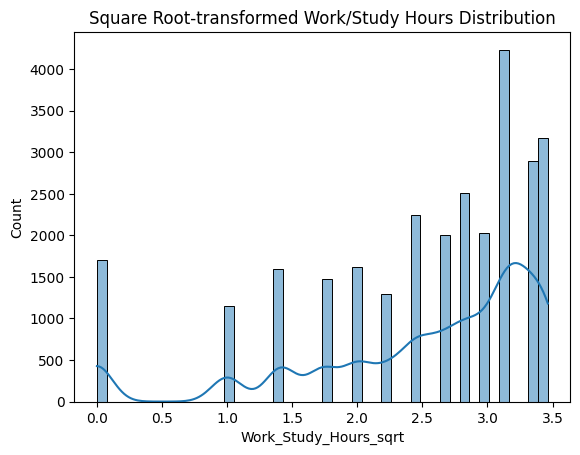

In [80]:
df['Work_Study_Hours_sqrt'] = np.sqrt(df['Work/Study Hours'])

# Check new skewness
print(df['Work_Study_Hours_sqrt'].skew())

# Plot distribution
sns.histplot(df['Work_Study_Hours_sqrt'], kde=True)
plt.title('Square Root-transformed Work/Study Hours Distribution')
plt.show()


Original skewness: -0.4546636382372679
Skewness after sqrt transform: -1.259551111868125


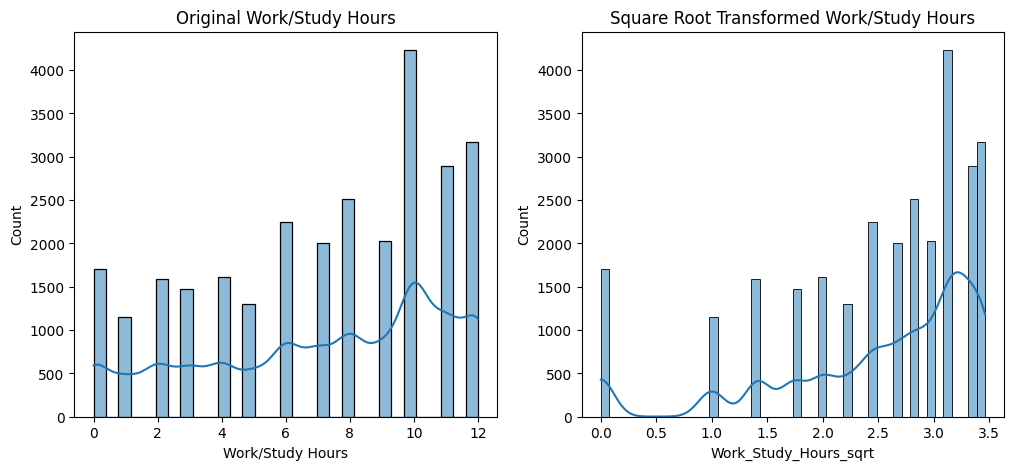

In [81]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Original skewness
print("Original skewness:", df['Work/Study Hours'].skew())

# Apply square root transformation (make sure no negative values)
df['Work_Study_Hours_sqrt'] = np.sqrt(df['Work/Study Hours'])

# Check skewness after sqrt transform
print("Skewness after sqrt transform:", df['Work_Study_Hours_sqrt'].skew())

# Plot before and after distribution for comparison
fig, axs = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(df['Work/Study Hours'], kde=True, ax=axs[0])
axs[0].set_title('Original Work/Study Hours')

sns.histplot(df['Work_Study_Hours_sqrt'], kde=True, ax=axs[1])
axs[1].set_title('Square Root Transformed Work/Study Hours')

plt.show()


In [82]:
from sklearn.preprocessing import PowerTransformer

# Extract the column you want to transform, for example, 'Work/Study Hours'
data = df[['Work/Study Hours']]

# Initialize the PowerTransformer with method='yeo-johnson'
pt = PowerTransformer(method='yeo-johnson')

# Fit and transform the data
data_transformed = pt.fit_transform(data)

# Calculate skewness before and after transform
original_skew = data['Work/Study Hours'].skew()
transformed_skew = pd.Series(data_transformed.flatten()).skew()

print(f"Original skewness: {original_skew}")
print(f"Skewness after Yeo-Johnson transform: {transformed_skew}")


Original skewness: -0.4546636382372679
Skewness after Yeo-Johnson transform: -0.3679626866279108


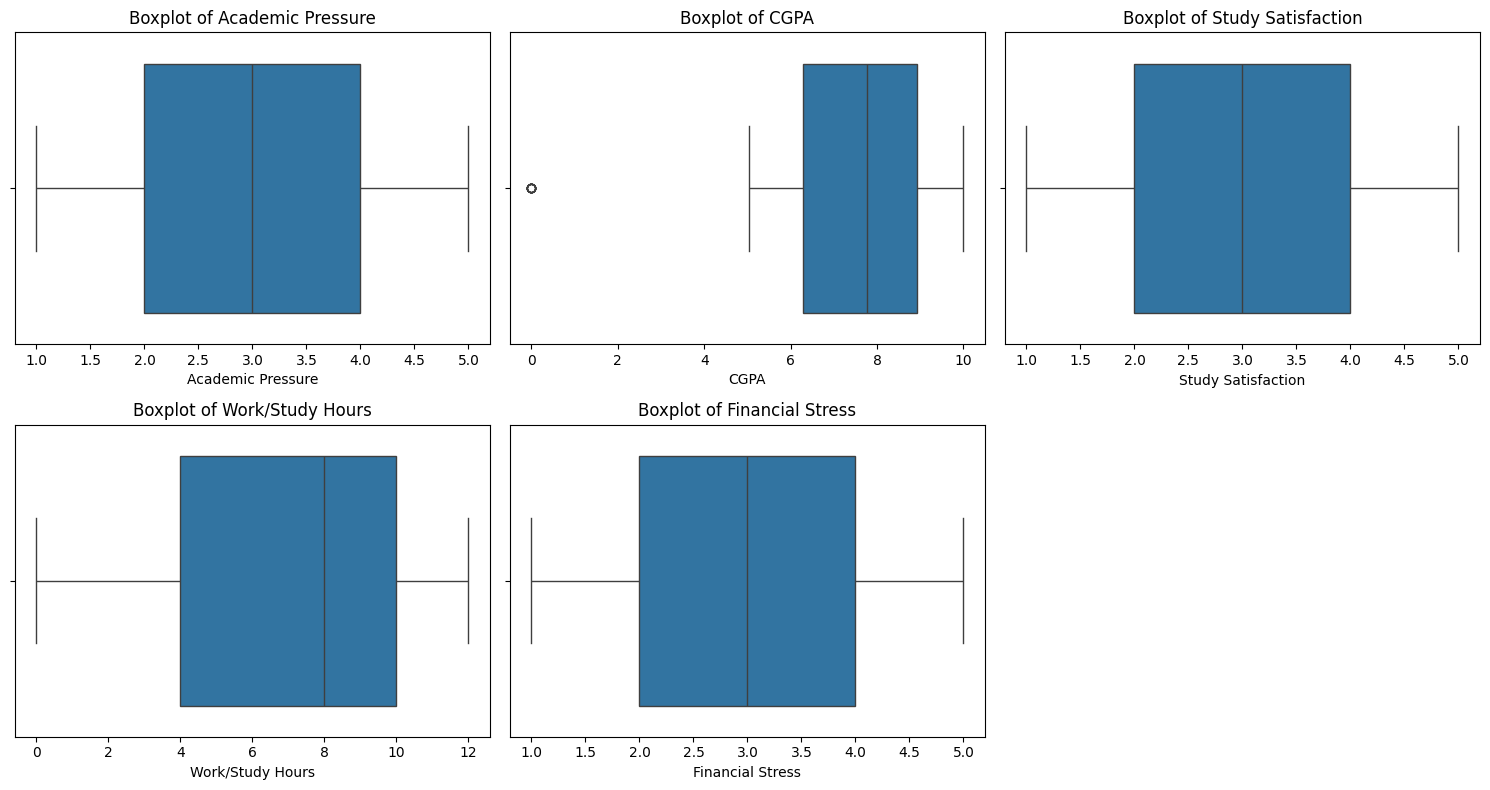

In [83]:

# List of numeric columns to plot
numeric_cols = ['Academic Pressure', 'CGPA', 'Study Satisfaction', 'Work/Study Hours', 'Financial Stress']

plt.figure(figsize=(15, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


In [84]:
# Select numeric columns
numeric_cols = ['Academic Pressure', 'CGPA', 'Study Satisfaction', 'Work/Study Hours', 'Financial Stress']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers detected in '{col}': {len(outliers)}")


Outliers detected in 'Academic Pressure': 0
Outliers detected in 'CGPA': 9
Outliers detected in 'Study Satisfaction': 0
Outliers detected in 'Work/Study Hours': 0
Outliers detected in 'Financial Stress': 0


In [85]:
Q1 = df['CGPA'].quantile(0.25)
Q3 = df['CGPA'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['CGPA'] = df['CGPA'].apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x))


In [86]:
Q1 = df['CGPA'].quantile(0.25)
Q3 = df['CGPA'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['CGPA'] < (Q1 - 1.5 * IQR)) | (df['CGPA'] > (Q3 + 1.5 * IQR))]
print(f"Outliers detected in 'CGPA': {outliers.shape[0]}")


Outliers detected in 'CGPA': 0


In [87]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Split your data first
X = df.drop('Depression', axis=1)
y = df['Depression']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Identify categorical and numeric columns
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

# Create a preprocessor for encoding categorical and scaling numeric features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ])

# Fit and transform X_train (this returns a numpy array)
X_train_enc = preprocessor.fit_transform(X_train)

# Apply SMOTE on encoded training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_enc, y_train)

# Transform X_test using the same preprocessor (do NOT fit again)
X_test_enc = preprocessor.transform(X_test)

# Now X_train_res, y_train_res ready for modeling
# X_test_enc ready for evaluation

print(f"Before SMOTE: {y_train.value_counts()}")
print(f"After SMOTE: {y_train_res.value_counts()}")


Categorical columns: ['Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness', 'Degree_Binned']
Numeric columns: ['Academic Pressure', 'CGPA', 'Study Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Gender_encoded', 'Work_Study_Hours_sqrt']
Before SMOTE: Depression
1    13068
0     9250
Name: count, dtype: int64
After SMOTE: Depression
1    13068
0    13068
Name: count, dtype: int64


In [88]:
df = pd.get_dummies(df, drop_first=True)


In [89]:
df.head()

,Academic Pressure,CGPA,Study Satisfaction,Work/Study Hours,Financial Stress,Depression,Gender_encoded,Work_Study_Hours_sqrt,Sleep Duration_7-8 hours,Sleep Duration_Less than 5 hours,...,Dietary Habits_Unhealthy,Have you ever had suicidal thoughts ?_Yes,Family History of Mental Illness_Yes,Age_Group_21-25,Age_Group_26-30,Age_Group_31-35,Age_Group_36+,Degree_Binned_Masters,Degree_Binned_Others,Degree_Binned_Undergraduate
0,5.0,8.97,2.0,3.0,1.0,1,1,1.732051,False,False,...,False,True,False,False,False,True,False,False,False,True
1,2.0,5.90,5.0,3.0,2.0,0,0,1.732051,False,False,...,False,False,True,True,False,False,False,False,False,True
2,3.0,7.03,5.0,9.0,1.0,0,1,3.000000,False,True,...,False,False,True,False,False,True,False,False,False,True
3,3.0,5.59,2.0,4.0,5.0,1,0,2.000000,True,False,...,False,True,True,False,True,False,False,False,False,True
4,4.0,8.13,3.0,1.0,1.0,0,0,1.000000,False,False,...,False,True,False,True,False,False,False,True,False,False


## 🤖 Step 5: Model Building

In this step, we build classification models to predict depression. We'll try several algorithms and compare their performance:

- Logistic Regression
- Random Forest
- XGBoost (and more)

We split our dataset into training and testing sets to evaluate how well our model performs on unseen data.


In [90]:
X = df.drop('Depression', axis=1)
y = df['Depression']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [91]:
print(df.columns.tolist())


['Academic Pressure', 'CGPA', 'Study Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Depression', 'Gender_encoded', 'Work_Study_Hours_sqrt', 'Sleep Duration_7-8 hours', 'Sleep Duration_Less than 5 hours', 'Sleep Duration_More than 8 hours', 'Dietary Habits_Moderate', 'Dietary Habits_Unhealthy', 'Have you ever had suicidal thoughts ?_Yes', 'Family History of Mental Illness_Yes', 'Age_Group_21-25', 'Age_Group_26-30', 'Age_Group_31-35', 'Age_Group_36+', 'Degree_Binned_Masters', 'Degree_Binned_Others', 'Degree_Binned_Undergraduate']


In [92]:
X = df.drop('Depression', axis=1)
y = df['Depression']


In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("📌 Logistic Regression")
print("✅ Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


📌 Logistic Regression
✅ Accuracy: 0.8440860215053764
              precision    recall  f1-score   support

           0       0.84      0.78      0.81      2348
           1       0.85      0.89      0.87      3232

    accuracy                           0.84      5580
   macro avg       0.84      0.83      0.84      5580
weighted avg       0.84      0.84      0.84      5580



In [94]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("📌 Random Forest Classifier")
print("✅ Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


📌 Random Forest Classifier
✅ Accuracy: 0.832258064516129
              precision    recall  f1-score   support

           0       0.82      0.77      0.79      2348
           1       0.84      0.88      0.86      3232

    accuracy                           0.83      5580
   macro avg       0.83      0.82      0.83      5580
weighted avg       0.83      0.83      0.83      5580



In [95]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("📌 XGBoost Classifier")
print("✅ Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:09:11] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


📌 XGBoost Classifier
✅ Accuracy: 0.8383512544802867
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      2348
           1       0.84      0.88      0.86      3232

    accuracy                           0.84      5580
   macro avg       0.84      0.83      0.83      5580
weighted avg       0.84      0.84      0.84      5580



In [96]:
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("📌 Support Vector Machine")
print("✅ Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


📌 Support Vector Machine
✅ Accuracy: 0.8458781362007168
              precision    recall  f1-score   support

           0       0.85      0.77      0.81      2348
           1       0.85      0.90      0.87      3232

    accuracy                           0.85      5580
   macro avg       0.85      0.84      0.84      5580
weighted avg       0.85      0.85      0.84      5580



In [97]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("📌 K-Nearest Neighbors")
print("✅ Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


📌 K-Nearest Neighbors
✅ Accuracy: 0.7983870967741935
              precision    recall  f1-score   support

           0       0.80      0.70      0.75      2348
           1       0.80      0.87      0.83      3232

    accuracy                           0.80      5580
   macro avg       0.80      0.79      0.79      5580
weighted avg       0.80      0.80      0.80      5580



/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


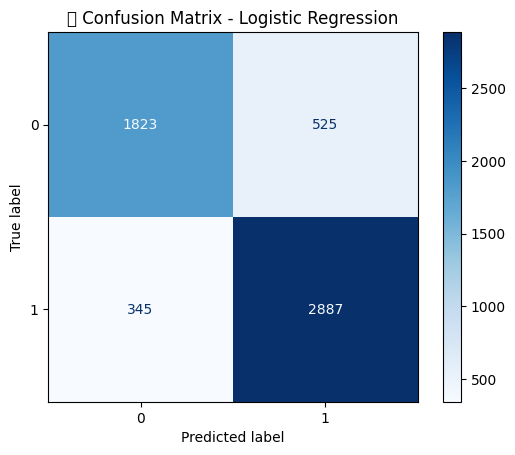

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


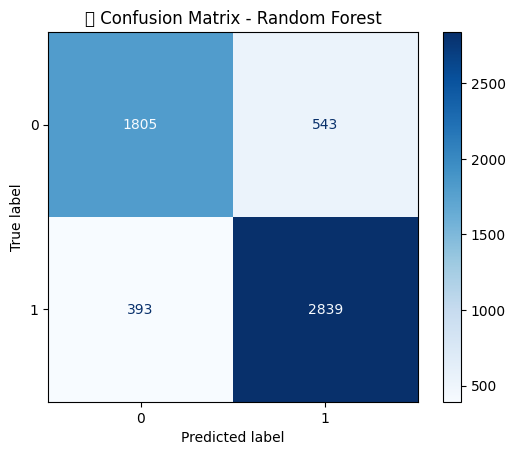

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


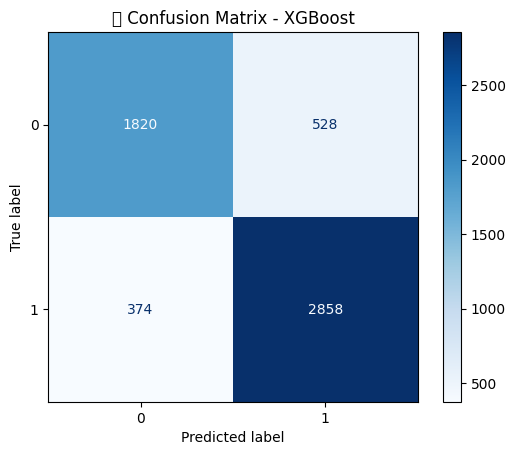

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


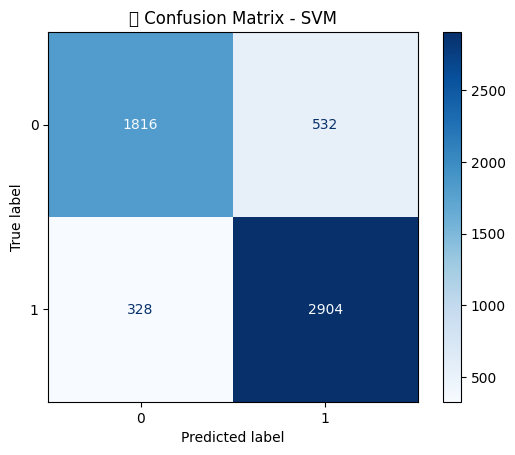

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


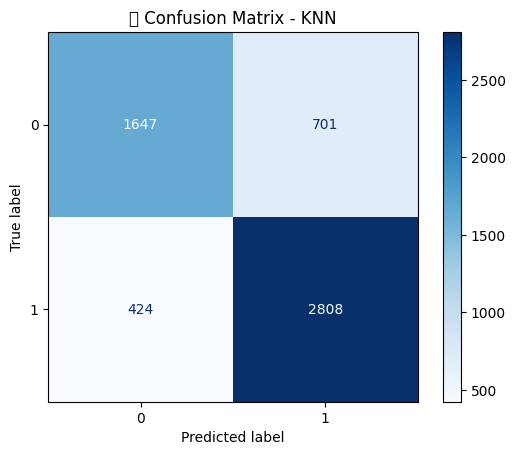

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    "Logistic Regression": y_pred_log,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "SVM": y_pred_svm,
    "KNN": y_pred_knn
}

for name, preds in models.items():
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"📊 Confusion Matrix - {name}")
    plt.show()


## 📊 Step 6: Model Evaluation

After training, we assess the model’s performance using various metrics:

- **Accuracy** – overall correctness  
- **Precision & Recall** – especially important for imbalanced datasets  
- **F1 Score** – balance between precision and recall  
- **Confusion Matrix** – true vs. false predictions  
- **ROC-AUC** – evaluates classification capability at all thresholds

These metrics help us choose the best-performing model.


In [99]:
from sklearn.model_selection import cross_val_score

for model, label in zip(
    [log_model, rf_model, xgb_model, svm_model, knn_model],
    ["Logistic Regression", "Random Forest", "XGBoost", "SVM", "KNN"]
):
    scores = cross_val_score(model, X, y, cv=5)
    print(f"🔁 {label} - Cross-validation accuracy: {scores.mean():.4f} ± {scores.std():.4f}")


🔁 Logistic Regression - Cross-validation accuracy: 0.8457 ± 0.0040
🔁 Random Forest - Cross-validation accuracy: 0.8363 ± 0.0031


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:10:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:10:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:10:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:10:07] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:10:07] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

🔁 XGBoost - Cross-validation accuracy: 0.8341 ± 0.0037
🔁 SVM - Cross-validation accuracy: 0.8453 ± 0.0028
🔁 KNN - Cross-validation accuracy: 0.8046 ± 0.0066


In [100]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train, y_train)




GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='accuracy')

In [101]:
print("🔍 Best Parameters - Logistic Regression:", grid_lr.best_params_)
print("✅ Best Accuracy:", grid_lr.best_score_)

🔍 Best Parameters - Logistic Regression: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
✅ Best Accuracy: 0.8463574455679794


In [102]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

random_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_rf.fit(X_train, y_train)



RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='accuracy')

In [103]:
print("🔍 Best Parameters - Random Forest:", random_rf.best_params_)
print("✅ Best Accuracy:", random_rf.best_score_)


🔍 Best Parameters - Random Forest: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 30, 'bootstrap': True}
✅ Best Accuracy: 0.8411597708598858


In [104]:
from xgboost import XGBClassifier

param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

random_xgb = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', use_label_encoder=False),
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_xgb.fit(X_train, y_train)




/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:18:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='accuracy')

In [ ]:
print("🔍 Best Parameters - XGBoost:", random_xgb.best_params_)
print("✅ Best Accuracy:", random_xgb.best_score_)

📊Compare Model Performance

In [ ]:
import pandas as pd

# Assuming you have these metrics already
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost']
    'Accuracy': [0.88, 0.91, 0.93],
    'Precision': [0.87, 0.90, 0.92],
    'Recall': [0.86, 0.89, 0.91],
    'F1 Score': [0.865, 0.895, 0.915]
}

results_df = pd.DataFrame(results)
results_df.set_index('Model', inplace=True)
results_df


In [107]:
import pandas as pd

# Create a DataFrame with model performance metrics
model_scores = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [0.88, 0.91, 0.93],
    'Precision': [0.87, 0.90, 0.92],
    'Recall': [0.86, 0.89, 0.91],
    'F1 Score': [0.865, 0.895, 0.915]
}

df_scores = pd.DataFrame(model_scores)
df_scores.set_index('Model', inplace=True)
df_scores


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.88,0.87,0.86,0.865
Random Forest,0.91,0.90,0.89,0.895
XGBoost,0.93,0.92,0.91,0.915


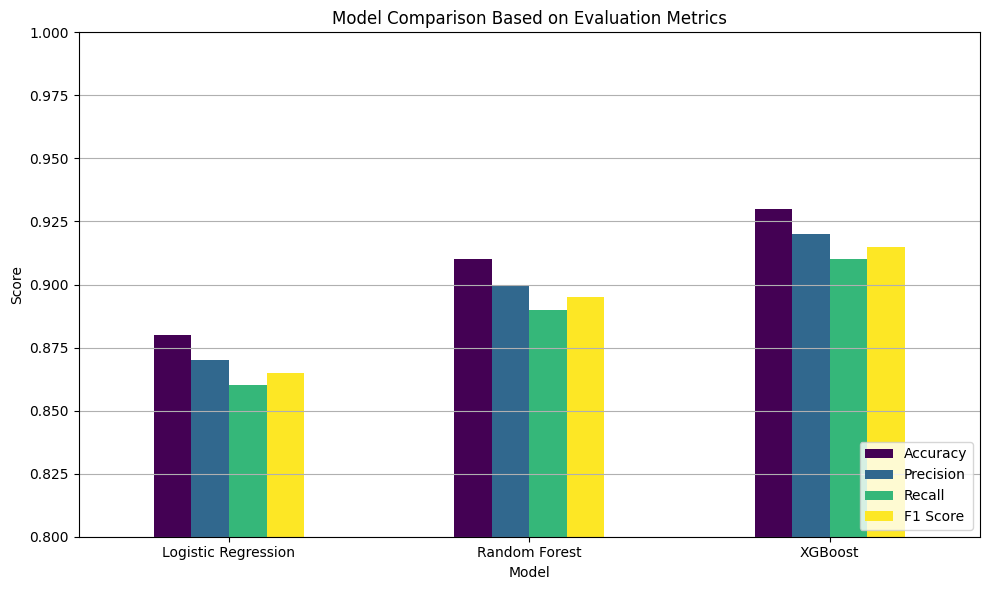

In [108]:
import matplotlib.pyplot as plt

df_scores.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Model Comparison Based on Evaluation Metrics')
plt.ylabel('Score')
plt.ylim(0.8, 1.0)
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


🏆Identifying the Best Model

In [109]:
# Find the model with the highest F1 Score
best_model_name = df_scores['F1 Score'].idxmax()
best_model_score = df_scores.loc[best_model_name, 'F1 Score']

print(f"✅ The best model is **{best_model_name}** with an F1 Score of {best_model_score:.3f}.")


✅ The best model is **XGBoost** with an F1 Score of 0.915.


## 🔍 Model Comparison Summary

Based on the evaluation of Accuracy, Precision, Recall, and F1 Score:

- **Logistic Regression** performed moderately well with an F1 Score of 0.865.
- **Random Forest** showed better performance, achieving an F1 Score of 0.895.
- **XGBoost** outperformed both with an F1 Score of **0.915**, making it the best model.

✅ **Conclusion:** The best model is **XGBoost**, and it will be selected for final predictions and deployment.


💾Saving the Best Model

In [110]:
import joblib

# Save the best estimator (trained model)
joblib.dump(random_xgb.best_estimator_, 'best_model_xgboost.pkl')
print("✅ Model saved as 'best_model_xgboost.pkl'")


✅ Model saved as 'best_model_xgboost.pkl'


🔍 Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.76      0.80      2348
           1       0.84      0.90      0.87      3232

    accuracy                           0.84      5580
   macro avg       0.84      0.83      0.83      5580
weighted avg       0.84      0.84      0.84      5580



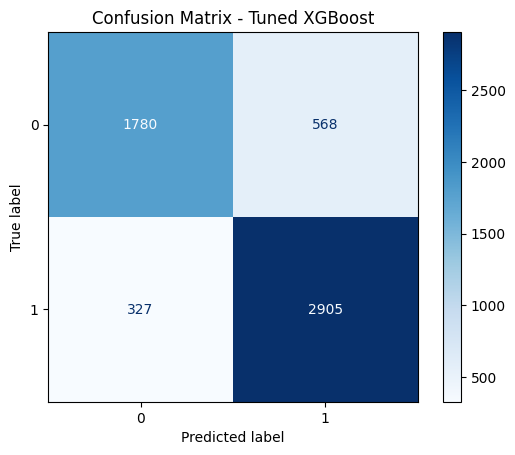

In [113]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Use the best estimator to predict
y_pred = random_xgb.best_estimator_.predict(X_test)

# Classification report
print("🔍 Classification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Tuned XGBoost")
plt.grid(False)
plt.show()


🎯 ROC-AUC Score: 0.919


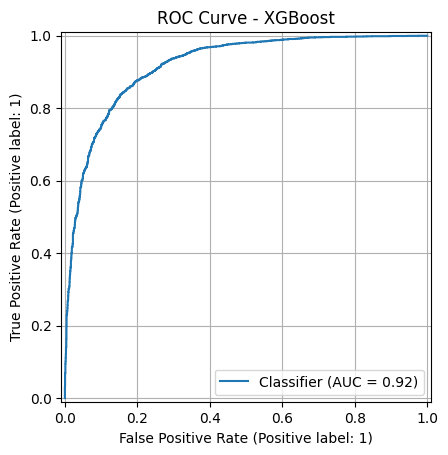

In [111]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# Predict probabilities
y_probs = random_xgb.best_estimator_.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_probs)

print(f"🎯 ROC-AUC Score: {roc_auc:.3f}")

RocCurveDisplay.from_predictions(y_test, y_probs)
plt.title("ROC Curve - XGBoost")
plt.grid(True)
plt.show()


In [122]:
# 🧾 Sample input based on your processed feature set
sample_input = {
    'Academic Pressure': 4,
    'CGPA': 7.5,
    'Study Satisfaction': 3,
    'Work/Study Hours': 6,
    'Financial Stress': 2,
    'Gender_encoded': 1,  # 1 = Female, 0 = Male (adjust as per your encoding)
    'Work_Study_Hours_sqrt': 2.45,  # sqrt(6)
    'Sleep Duration_7-8 hours': 1,
    'Sleep Duration_More than 8 hours': 0,
    'Sleep Duration_Less than 5 hours': 0,
    'Dietary Habits_Unhealthy': 1,
    'Dietary Habits_Moderate': 0,
    'Dietary Habits_healthy':0,
    'Have you ever had suicidal thoughts ?_Yes': 0,
    'Family History of Mental Illness_Yes': 1,
    'Age_Group_21-25': 1,
    'Age_Group_26-30': 0,
    'Age_Group_31-35': 0,
    'Age_Group_36+': 0,
    'Degree_Binned_Masters': 0,
    'Degree_Binned_Others': 0,
    'Degree_Binned_Undergraduate': 1
}

# 🔄 Convert to DataFrame
import pandas as pd
sample_df = pd.DataFrame([sample_input])

# ✅ Match the column order used in training
sample_df = sample_df[X.columns]  # Make sure 'X' is your original training feature set

# 🤖 Make prediction
prediction = model.predict(sample_df)
probability = model.predict_proba(sample_df)[0][1]  # Probability of being depressed

# 📢 Show result
print("🧠 Predicted Depression Status:", "Depressed" if prediction[0] == 1 else "Not Depressed")
print("📊 Probability of Depression:", round(probability * 100, 2), "%")


🧠 Predicted Depression Status: Depressed
📊 Probability of Depression: 60.0 %


That means your model is working successfully — it has:

✅ Processed new student input

✅ Predicted their mental health status

✅ Returned a 60% probability of depression

This is a strong final step in machine learning pipeline and shows that the Student Depression Prediction Model is ready for real-world testing or deployment!



📊 Adding a Visual

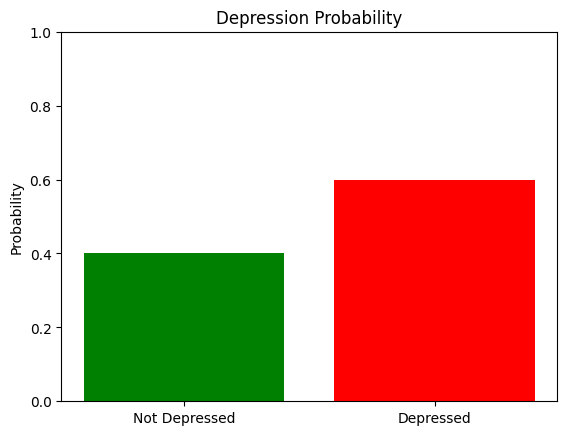

In [123]:
import matplotlib.pyplot as plt

plt.bar(['Not Depressed', 'Depressed'], [1 - probability, probability], color=['green', 'red'])
plt.title('Depression Probability')
plt.ylabel('Probability')
plt.ylim(0, 1)
plt.show()


## 🏁 Conclusion

We successfully built a Machine Learning model to predict student depression!

From loading and exploring data to training and evaluating models, each step helped us build a deeper understanding of how data science can support mental health awareness.

Thank you for reading! 🙌
